# LHS/Sobol'-FMQAによる初期学習データ生成

LHS/Sobol'-FMQAは，ブラックボックス最適化手法であるfactorization machine with quadratic-optimization annealing（FMQA）の初期学習データ生成を改良する手法である．本チュートリアルでは，Latin hypercube sampling（LHS）またはSobol'準ランダム列を用いて，FMQAの初期学習データを生成する．


[T. Hayashi et al., "Improving FMQA via Initial Training Data Design Considering Marginal Bit Coverage in One-Hot Encoding" arXiv:2605.04825 (2026)](https://arxiv.org/abs/2605.04825)

## FMQAの概要

Factorization Machine with Quadratic-optimization Annealing (FMQA)[1] は，Factorization Machine (FM) とイジングマシン（量子アニーリングなど）を組み合わせたブラックボックス最適化手法である．目的関数の評価コストが高い問題（例：第一原理計算や大規模シミュレーション，実験を伴う最適化）に対して，少ない評価回数で最適解を探索できる特徴を持つ．

[1] [K. Kitai et al., Phys. Rev. Res., 2, 013319 (2020).](https://journals.aps.org/prresearch/abstract/10.1103/PhysRevResearch.2.013319)

### FMQAの最適化手順

FMの出力は，パラメータ $\boldsymbol{\theta} \equiv (\omega_0, \{\omega_i\}_{i=1}^N, \{\boldsymbol{v}_i\}_{i=1}^N)$ を用いて以下の2次多項式で表される：

$$
f_{\mathrm{FM}}(\boldsymbol{x}; \boldsymbol{\theta}) = \omega_0 + \sum_{i=1}^N \omega_i x_i + \sum_{1 \le i < j \le N} \langle \boldsymbol{v}_i, \boldsymbol{v}_j \rangle x_i x_j.
$$

FMQAは，以下の手順 (Step 1〜4) を繰り返すことでブラックボックス (BB) 関数 $f_{\mathrm{BB}}$ の最適化を行う：

**Step 1: 初期学習データの生成**
BB関数に対する初期入力 $\{\boldsymbol{x}_d\}_{d=1}^{N_0}$ を生成し，評価することで，初期学習データセット $\mathcal{D}_0 = \{ (\boldsymbol{x}_d, f_{\mathrm{BB}}(\phi(\boldsymbol{x}_d))) \}_{d=1}^{N_0}$ を取得する（ここで $\phi$ はデコード関数）．

**Step 2: FMサロゲートモデルの学習**
データセット $\mathcal{D}_n$ を用い，以下の平均二乗誤差 (MSE) を損失関数としてFMモデルを学習させ，BB関数を近似するパラメータ $\hat{\boldsymbol{\theta}}_n$ を得る．

$$
L(\boldsymbol{\theta}) = \frac{1}{D} \sum_{d=1}^D \left( f_{\mathrm{FM}}(\boldsymbol{x}_d; \boldsymbol{\theta}) - f_{\mathrm{BB}}(\phi(\boldsymbol{x}_d)) \right)^2.
$$

**Step 3: イジングマシンを用いた候補解の探索**
学習済みのFMモデル $f_{\mathrm{FM}}(\boldsymbol{x}; \hat{\boldsymbol{\theta}}_n)$ は，以下の行列 $Q$ を持つQUBO（2次制約なし二値最適化）形式に変換できる：

$$
Q_{i,j} = \begin{cases} \omega_i, & (i=j), \\ \langle \boldsymbol{v}_i, \boldsymbol{v}_j \rangle, & (i \ne j). \end{cases}
$$

イジングマシンを用いて，QUBOエネルギー $E_{\mathrm{QUBO}}(\boldsymbol{x}) = \sum_{1 \le i \le j \le N} Q_{i,j} x_i x_j$ を最小化する候補解 $\boldsymbol{x}_{\mathrm{new}}$ を探索する．

**Step 4: BB関数の評価とデータセットの更新**
得られた候補解 $\boldsymbol{x}_{\mathrm{new}}$ をBB関数で評価し，$f_{\mathrm{BB}}(\phi(\boldsymbol{x}_{\mathrm{new}}))$ を得る．この新しいデータ点をデータセットに追加し，$\mathcal{D}_{n+1} = \mathcal{D}_n \cup \{ (\boldsymbol{x}_{\mathrm{new}}, f_{\mathrm{BB}}(\phi(\boldsymbol{x}_{\mathrm{new}}))) \}$ とする．その後，Step 2 に戻る．

本チュートリアル（LHS/Sobol'-FMQA）では，**Step 1** において，単純なランダムサンプリングの代わりに LHS や Sobol' 列を用いる手法について解説する．

## LHS/Sobol'-FMQAの手順

1. LHSまたはSobol'準ランダム列を用いて，$[0, 1)$上の連続値を生成する．
2. 各変数の定義域へスケーリングし，初期学習データ$x^{(d)}$を得る．
3. ブラックボックス関数の出力値$y^{(d)} = f_{\mathrm{BB}}(x^{(d)})$を得る．
4. 同じ初期学習データを離散化し，one-hotエンコーディング後の各ビットの網羅性を確認する．
5. 初期学習データセット$\mathcal{D}_0 = \{(x^{(d)}, y^{(d)})\}$を構築し，FMQAを実行する．

本チュートリアルでは、初期学習データの分布（網羅性）を事前に可視化して確認するため、手動で初期データを生成してからFMQAを実行します。
（実用時は `run` 関数の引数に `sampling_method` 等を指定することで、手動で生成することなく全自動で実行可能です。）

### 計算環境の準備

[Fixstars Amplify AEの利用方法](https://g-quat-abciq.github.io/abciq-docs/ja/apps/amplify-ae/)を参照して，必要ライブラリをインストールするための仮想環境を作成する．そして，仮想環境内に`amplify`と`amplify-bbopt`をインストールする．

```bash
python3 -m pip install -U amplify amplify-bbopt
```

また，`amplify-bbopt-ext`ライブラリを追加する．

```bash
python3 -m pip install git+https://github.com/Shu-Tanaka-Group/amplify-bbopt-ext.git
```

Fixstars Amplify AEを用いてFMQAまで実行する場合は，ABCI-QなどのAmplify AEへ接続できる計算環境が必要である．初期学習データ生成，ブラックボックス関数の呼び出しおよび各ビットの網羅性の確認には，Amplify AEへの接続は不要である。

### 必要ライブラリの読み込み

In [10]:
!pip install git+https://github.com/taiga-hayashi/amplify-bbopt-ext.git


In [11]:
import amplify_bbopt
from datetime import timedelta

import numpy as np
from amplify import FixstarsClient
from amplify_bbopt import DiscretizationSpec, RealVariable, blackbox


from amplify_bbopt_ext.initial_sampling import generate


In [12]:
amplify_bbopt.__version__

'1.2.0'

### パラメータ設定

主な変更箇所は次のセルである．Sobol'準ランダム列では任意の正の初期学習データ数を指定できるが，balance特性を保つため，`n_init_data = 2**m`を推奨する．2のべき乗でない場合も処理は停止せず，警告を表示して指定された初期学習データ数を生成する．

In [13]:
# ===== 利用者が変更する設定 =====
n_variables = 2
bounds = (-3.0, 3.0)
n_bins = 32
sampling_method = "lhs"  # "lhs" または "sobol"
n_init_data = 32
seed = 42
scramble = True

# Amplify AEへ接続できる環境でFMQAまで実行する場合のみTrueにする．
run_fmqa = True

lower_bounds = np.full(n_variables, bounds[0])
upper_bounds = np.full(n_variables, bounds[1])

### ブラックボックス関数の設定

本チュートリアルでは，ブラックボックス関数のベンチマークとしてRastrigin関数を用いる．`initial_data`に格納された連続値をブラックボックス関数へ入力し，その出力値を取得する．`RealVariable`の離散化設定は，FMQAにおける入力値のエンコーディングに使用される．

In [14]:
disc_spec = DiscretizationSpec(num_bins=n_bins)
x_list = [
    RealVariable(bounds, discretization_spec=disc_spec)
    for _ in range(n_variables)
]


def rastrigin(x: list[float] | np.ndarray) -> float:
    x_array = np.asarray(x, dtype=float)
    return float(
        10 * x_array.size
        + np.sum(x_array**2 - 10 * np.cos(2 * np.pi * x_array))
    )


@blackbox
def bb_func(input_x: list[float] = x_list) -> float:  # type: ignore
    return rastrigin(input_x)

### ブラックボックス関数の呼び出し

各初期学習データ$x^{(d)}$について，ブラックボックス関数の出力値$y^{(d)} = f(x^{(d)})$を取得する．`initial_data`と`initial_objectives`は，元コードの`scaled_vals_init`と`y_init`にそれぞれ対応する．

In [16]:
initial_objectives = np.array([rastrigin(x) for x in initial_data])
print(f"初期学習データにおける目的関数の最良値: {initial_objectives.min():.6f}")
initial_objectives[:5]

初期学習データにおける目的関数の最良値: 6.035446


array([23.31448573, 23.28755382, 29.30725692, 37.20011184, 37.09898184])

### 初期学習データの手動生成

最適化を実行する前に、初期学習データがどのように空間を埋めているかを確認するため、手動でサンプルを生成します。

In [ ]:
# 用意した関数を用いて初期データを生成します。
initial_data = generate(
    sampling_method,
    n_init_data,
    lower_bounds=lower_bounds,
    upper_bounds=upper_bounds,
    seed=seed,
)


### 各ビットの網羅性の確認

最適化の履歴 (`result.history`) から初期学習データとして生成されたサンプルを取り出し、離散化（ビン割り当て）を行ったうえで、各ビン（＝各ビット）が何回選ばれたかを確認します。

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# FMQAの実行履歴から初期学習データ部分だけを抽出

# 各ビンのインデックスを計算
discrete_indices = np.empty_like(initial_data, dtype=int)
for i in range(n_variables):
    bin_edges = np.linspace(lower_bounds[i], upper_bounds[i], n_bins + 1)
    discrete_indices[:, i] = np.clip(np.digitize(initial_data[:, i], bin_edges) - 1, 0, n_bins - 1)

# 各ビットの選ばれた回数をプロット
fig, axes = plt.subplots(
    1,
    n_variables,
    figsize=(4 * n_variables, 3),
    squeeze=False,
)
for index in range(n_variables):
    axes[0, index].hist(
        discrete_indices[:, index],
        bins=np.arange(n_bins + 1) - 0.5,
        rwidth=0.9,
    )
    axes[0, index].set_xlabel(f"Bin index for x{index + 1}")
    axes[0, index].set_ylabel("Count")
    axes[0, index].yaxis.set_major_locator(MaxNLocator(integer=True))
    
fig.suptitle("Initial Data Coverage", fontsize=14)
plt.tight_layout()
plt.show()


### FMQAの実行

Fixstars Amplify AEへ接続できる計算環境でFMQAまで実行する場合は，パラメータ設定セルの`run_fmqa`を`True`に変更する．既定値の`False`では，FMQAの実行のみをスキップする．

`LatestDatasetOptimizer`は初期学習データの入力値を内部でエンコーディングするため，本チュートリアル内でone-hotベクトルを構築する必要はない．

In [22]:
result = None
if run_fmqa:
    from amplify_bbopt_ext.runner import run

    client = FixstarsClient()
    client.token = "YOUR_TOKEN_HERE"
    client.parameters.timeout = timedelta(milliseconds=1000)
    client.parameters.num_gpus = 1

    import logging
    logging.getLogger("amplify_bbopt").setLevel(logging.WARNING)

    result = run(
        client=client,
        bb_func=bb_func,
        size_limit=200,
        k=8,
        n_iter=80,
        # 今回は上で可視化した初期データをそのまま渡します。
        initial_data=initial_data,
        # 
        # sampling_method=sampling_method,
        # n_init_data=n_init_data,
        # lower_bounds=lower_bounds,
        # upper_bounds=upper_bounds,
        # seed=seed,
        # scramble=scramble,
        epochs=1000,
        optimizer_params={"lr": 0.01},
    )
    print(result.best.values)
    print(result.best.objective)
else:
    print("FMQAの実行をスキップした．Amplify AE環境ではrun_fmqa=Trueに設定する．")

## 結果の可視化

初期学習データにおけるブラックボックス関数の出力値の推移を表示する．FMQAを実行した場合は，`result.training_data`および`result.history`から最適化プロセスの履歴を取得できる．

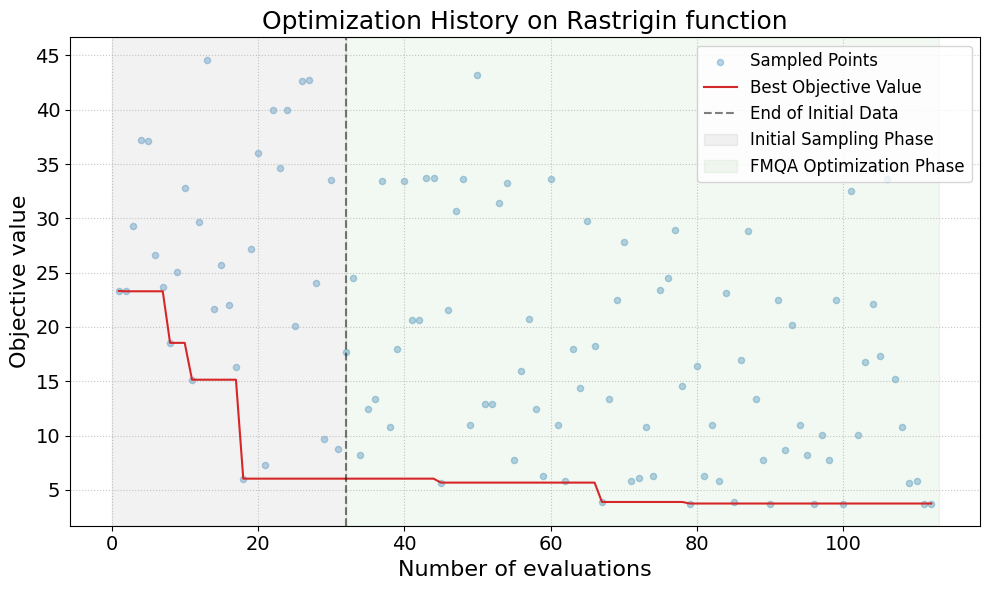

In [25]:
import numpy as np

if run_fmqa:
    # 最適化履歴からこれまでの最小値（Best Objective Value）の推移を計算
    y_history = result.training_data._y
    best_y = np.minimum.accumulate(y_history)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    n_initial = len(initial_data)
    
    # 評価回数（x軸）は 1 からスタート
    x_evals = np.arange(1, len(best_y) + 1)
    
    # 全サンプリング点の散布図
    ax.scatter(x_evals, y_history, color='tab:blue', alpha=0.3, label='Sampled Points', s=20)
    
    # これまでの最小値の推移の折れ線
    ax.plot(x_evals, best_y, linestyle='-', color='tab:red', label='Best Objective Value', markersize=6)
    
    # フェーズの境界線
    ax.axvline(x=n_initial, color='k', linestyle='--', alpha=0.5, label='End of Initial Data')
    
    # 背景を色分けしてフェーズを区別
    ax.axvspan(0, n_initial, alpha=0.1, color='gray', label='Initial Sampling Phase')
    ax.axvspan(n_initial, len(best_y) + 1, alpha=0.05, color='green', label='FMQA Optimization Phase')
    
    ax.set_xlabel('Number of evaluations', fontsize=16)
    ax.set_ylabel('Objective value', fontsize=16)
    ax.set_title('Optimization History on Rastrigin function', fontsize=18)
    ax.legend(fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    # FMQAを実行しない場合は、初期学習データの目的関数値をプロット
    y_initial = np.array([bb_func(x) for x in initial_data])
    best_y_init = np.minimum.accumulate(y_initial)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    x_evals = np.arange(1, len(best_y_init) + 1)
    
    # 全サンプリング点の散布図
    ax.scatter(x_evals, y_initial, color='tab:blue', alpha=0.4, label='Sampled Points (Initial)', s=20)
    
    # これまでの最小値の推移の折れ線
    ax.plot(x_evals, best_y_init, linestyle='-', color='tab:red', label='Best Objective Value (Initial)', markersize=6)
    
    ax.set_xlabel('Number of evaluations', fontsize=16)
    ax.set_ylabel('Objective value', fontsize=16)
    ax.set_title('Evaluation History of Initial Data on Rastrigin function', fontsize=18)
    ax.legend(fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()




## パラメータ設定のTips

- `n_init_data`：初期学習データ数を表す．値を大きくすると各ビットの網羅性を満たしやすくなる一方で，ブラックボックス関数の呼び出し回数が増加する．
- Sobol'準ランダム列では任意の正の`n_init_data`を指定できるが，balance特性を保つため2のべき乗を推奨する．
- `scramble=True`：scramblingを有効にする．`seed`を固定することで初期学習データを再現できる．
- LHSとSobol'準ランダム列を比較する場合は，ブラックボックス関数，変数の定義域，離散点数，初期学習データ数，FMのハイパーパラメータおよび試行回数を揃える．
- 離散変数またはカテゴリ変数を直接扱う場合は，`map_unit_samples_to_discrete`を用いて，単位超立方体上の点を各変数の候補値へ写像する．

## LHS/Sobol'-FMQAの引用

```bibtex
@article{hayashi2026initialdata,
  title={Improving FMQA via Initial Training Data Design Considering Marginal Bit Coverage in One-Hot Encoding},
  author={Hayashi, Taiga and Seki, Yuya and Terada, Kotaro and Mukasa, Yosuke and Kikuchi, Shuta and Tanaka, Shu},
  journal={arXiv preprint arXiv:2605.04825},
  year={2026}
}
```